# Initial Setup

Before beginning the assignment, we import the CIFAR dataset, and train a simple convolutional neural network (CNN) to classify it.

**Scope note:** In this assignment we implement *static* post-training quantization (PTQ) only. Dynamic PTQ (where scale factors are computed at inference time) is not covered. We also explore *pruning* as a complementary model compression technique in Q6 and Q7.

In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

**Reminder:** set the runtime type to "GPU", or your code will run much more slowly on a CPU.

In [5]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

Load training and test data from the CIFAR10 dataset.

In [6]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


Define a simple CNN that classifies CIFAR images.

In [7]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # in_channels, out_channels, kernel_size
        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1 = nn.Linear(16 * 5 * 5, 120, bias=False)
        self.fc2 = nn.Linear(120, 84, bias=False)
        self.fc3 = nn.Linear(84, 10, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net().to(device)

Train this CNN on the training dataset (this may take a few moments).

**Training time note:** This cell triggers an approximately 5-minute training run on GPU. Make sure your runtime is set to GPU before starting. A second training run occurs in Q5 for `NetWithBias`.

In [8]:
from torch.utils.data import DataLoader

def train(model: nn.Module, dataloader: DataLoader):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

    for epoch in range(2):  # loop over the dataset multiple times

        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                    (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')

def test(model: nn.Module, dataloader: DataLoader, max_samples=None) -> float:
    correct = 0
    total = 0
    n_inferences = 0

    with torch.no_grad():
        for data in dataloader:
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if max_samples:
                n_inferences += images.shape[0]
                if n_inferences > max_samples:
                    break

    return 100 * correct / total

In [9]:
train(net, trainloader)

[1,  2000] loss: 2.211
[1,  4000] loss: 1.829
[1,  6000] loss: 1.695
[1,  8000] loss: 1.621
[1, 10000] loss: 1.549
[1, 12000] loss: 1.499
[2,  2000] loss: 1.421
[2,  4000] loss: 1.422
[2,  6000] loss: 1.386
[2,  8000] loss: 1.393
[2, 10000] loss: 1.375
[2, 12000] loss: 1.332
Finished Training


Now that the CNN has been trained, let's test it on our test dataset.

In [10]:
score = test(net, testloader)
print('Accuracy of the network on the test images: {}%'.format(score))

Accuracy of the network on the test images: 48.69%


In [11]:
from copy import deepcopy

# A convenience function which we use to copy CNNs.
# This deep-copies a model including custom metadata like activation hooks and scale
# factors that copy.deepcopy alone does not capture (e.g., layer.weight.scale,
# layer.activations, and model.input_activations).
def copy_model(model: nn.Module) -> nn.Module:
    result = deepcopy(model)

    # Copy over the extra metadata we've collected which copy.deepcopy doesn't capture
    if hasattr(model, 'input_activations'):
        result.input_activations = deepcopy(model.input_activations)

    for result_layer, original_layer in zip(result.children(), model.children()):
        if isinstance(result_layer, nn.Conv2d) or isinstance(result_layer, nn.Linear):
            if hasattr(original_layer.weight, 'scale'):
                result_layer.weight.scale = deepcopy(original_layer.weight.scale)
            if hasattr(original_layer, 'activations'):
                result_layer.activations = deepcopy(original_layer.activations)
            if hasattr(original_layer, 'output_scale'):
                result_layer.output_scale = deepcopy(original_layer.output_scale)

    return result

# Question 1: Visualize Weights

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
for name, layer in net.named_children():
    print(f"Layer Name: {name} | Layer Type: {type(layer).__name__}")

Layer Name: conv1 | Layer Type: Conv2d
Layer Name: pool | Layer Type: MaxPool2d
Layer Name: conv2 | Layer Type: Conv2d
Layer Name: fc1 | Layer Type: Linear
Layer Name: fc2 | Layer Type: Linear
Layer Name: fc3 | Layer Type: Linear


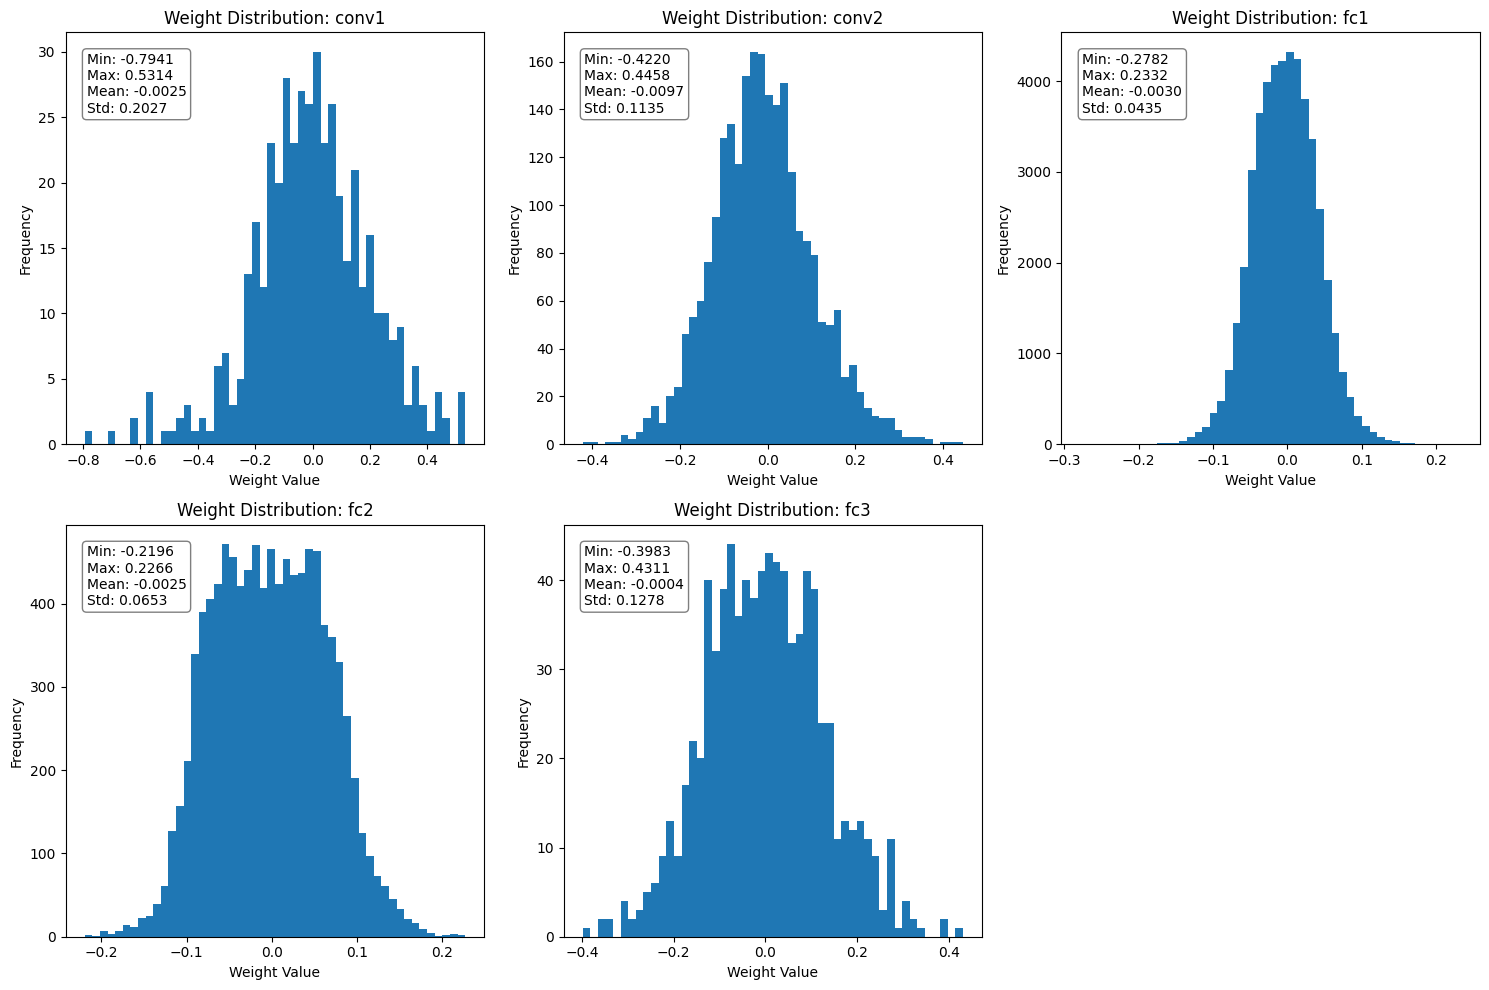

In [14]:
# ADD YOUR CODE HERE to plot distributions of weights

layers_to_plot = [
    (name, layer) for name, layer in net.named_children()
    if "conv" in name.lower() or "fc" in name.lower()
]

plt.figure(figsize=(15, 10))

for i, (name, layer) in enumerate(layers_to_plot, 1):
    plt.subplot(2, 3, i)

    weights = layer.weight.data.cpu().view(-1)

    w_min = torch.min(weights).item()
    w_max = torch.max(weights).item()
    w_mean = torch.mean(weights).item()
    w_std = torch.std(weights).item()

    plt.hist(weights.numpy(), bins=50)
    plt.title(f'Weight Distribution: {name}')

    # This annotation section was generated with Gemini
    stats_text = f'Min: {w_min:.4f}\nMax: {w_max:.4f}\nMean: {w_mean:.4f}\nStd: {w_std:.4f}'
    plt.annotate(stats_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.xlabel('Weight Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Temp Scratchpad
Input is shape (batch size, channel, x, y)
For input (1,3,32,32), conv2d shape (6,3,5,5) has a unique 5x5 kernel for each channel, and has 6 of these. It sums over channels at the end to produce 6,28,28

In [15]:
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo
    from torchinfo import summary

# Using 'kernel_size' to show the shape of the weight tensors
summary(net, input_size=(1, 3, 32, 32), col_names=["output_size", "kernel_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Kernel Shape              Param #
Net                                      [1, 10]                   --                        --
├─Conv2d: 1-1                            [1, 6, 28, 28]            [5, 5]                    450
├─MaxPool2d: 1-2                         [1, 6, 14, 14]            2                         --
├─Conv2d: 1-3                            [1, 16, 10, 10]           [5, 5]                    2,400
├─MaxPool2d: 1-4                         [1, 16, 5, 5]             2                         --
├─Linear: 1-5                            [1, 120]                  --                        48,000
├─Linear: 1-6                            [1, 84]                   --                        10,080
├─Linear: 1-7                            [1, 10]                   --                        840
Total params: 61,770
Trainable params: 61,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.65
Input si

In [16]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images = images.to(device)

# Run the forward pass
output = net(images)

print(f"Input batch shape: {images.shape}")
print(f"Output batch shape: {output.shape}")
print(f"Labels for this batch: {labels}")
print(f"Number of classes in output: {output.shape[1]}")

Input batch shape: torch.Size([4, 3, 32, 32])
Output batch shape: torch.Size([4, 10])
Labels for this batch: tensor([3, 8, 8, 0])
Number of classes in output: 10


In [17]:
# Accessing the weight tensor of the first convolutional layer
conv1_weight_shape = net.conv1.weight.shape
print(f"Shape of conv1 weights: {conv1_weight_shape}")
print(f"This represents: [out_channels, in_channels, height, width]")

Shape of conv1 weights: torch.Size([6, 3, 5, 5])
This represents: [out_channels, in_channels, height, width]


### Comparison: Per-Tensor vs. Per-Channel Quantization
We can calculate the scales for `conv1` weights using both methods to see the difference.

In [18]:
weights = net.conv1.weight.data

# 1. Per-Tensor Scaling
# One scale for all 6 filters
tensor_max = torch.max(torch.abs(weights))
per_tensor_scale = 127.0 / tensor_max
print(f"Per-Tensor Scale: {per_tensor_scale.item():.4f}")

# 2. Per-Channel Scaling
# One scale for each of the 6 output channels
# weights.view(6, -1) flattens the [3, 5, 5] part for each filter
channel_maxes = torch.max(torch.abs(weights.view(6, -1)), dim=1).values
per_channel_scales = 127.0 / channel_maxes

print("\nPer-Channel Scales (one for each filter):")
for i, s in enumerate(per_channel_scales):
    print(f" Filter {i}: {s.item():.4f}")

Per-Tensor Scale: 159.9342

Per-Channel Scales (one for each filter):
 Filter 0: 208.0662
 Filter 1: 371.5706
 Filter 2: 292.2437
 Filter 3: 159.9342
 Filter 4: 266.8669
 Filter 5: 247.6925


# Question 2: Quantize Weights

In [19]:
net_q2 = copy_model(net)

In [20]:
from typing import Tuple

def quantized_weights(weights: torch.Tensor) -> Tuple[torch.Tensor, float]:
    '''
    Quantize the weights so that all values are integers between -128 and 127.
    You may want to use the total range, 3-sigma range, or some other range when
    deciding just what factors to scale the float32 values by.

    Parameters:
    weights (Tensor): The unquantized weights

    Returns:
    (Tensor, float): A tuple with the following elements:
                        * The weights in quantized form, where every value is an integer between -128 and 127.
                          The "dtype" will still be "float", but the values themselves should all be integers.
                        * The scaling factor that your weights were multiplied by.
                          This value does not need to be an 8-bit integer.
    '''

    # ADD YOUR CODE HERE
    # TODO: Replace the placeholder scale below with a formula derived from the
    # actual weight values.

    # asymmetric quantization (this implementation severely degrades performance
    # which is likely due to the zero point, explained in report)
    # max = torch.max(weights)
    # min = torch.min(weights)
    # output_max = 127
    # output_min = -128
    # scale = (max - min) / (output_max - output_min)
    # zero_point = (output_min - min / scale).round()
    # result = (weights / scale + zero_point).round()
    # return torch.clamp(result, min=-128, max=127), scale

    # symmetric quantization
    scale = 2 * torch.max(torch.abs(weights)) / (2**8 - 1)
    result = (weights / scale).round()
    return torch.clamp(result, min=-128, max=127), scale

    # max = torch.max(weights)
    # min = torch.min(weights)
    # output_max = 127
    # output_min = -128
    # scale = (max - min) / (output_max - output_min)
    # result = (weights / scale).round()
    # return torch.clamp(result, min=-128, max=127), scale

In [21]:
def quantize_layer_weights(model: nn.Module):
    for layer in model.children():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            q_layer_data, scale = quantized_weights(layer.weight.data)
            q_layer_data = q_layer_data.to(device)

            layer.weight.data = q_layer_data
            layer.weight.scale = scale

            if (q_layer_data < -128).any() or (q_layer_data > 127).any():
                raise Exception("Quantized weights of {} layer include values out of bounds for an 8-bit signed integer".format(layer.__class__.__name__))
            if (q_layer_data != q_layer_data.round()).any():
                raise Exception("Quantized weights of {} layer include non-integer values".format(layer.__class__.__name__))

quantize_layer_weights(net_q2)

In [22]:
score = test(net_q2, testloader)
print('Accuracy of the network after quantizing all weights: {}%'.format(score))

Accuracy of the network after quantizing all weights: 48.53%


# Question 3: Visualize Activations

In [23]:
def register_activation_profiling_hooks(model: nn.Module):
    model.input_activations = np.empty(0)
    model.conv1.activations = np.empty(0)
    model.conv2.activations = np.empty(0)
    model.fc1.activations = np.empty(0)
    model.fc2.activations = np.empty(0)
    model.fc3.activations = np.empty(0)

    model.profile_activations = True

    def conv1_activations_hook(layer, x, y):
        if model.profile_activations:
            model.input_activations = np.append(model.input_activations, x[0].cpu().view(-1))
    model.conv1.register_forward_hook(conv1_activations_hook)

    def conv2_activations_hook(layer, x, y):
        if model.profile_activations:
            model.conv1.activations = np.append(model.conv1.activations, x[0].cpu().view(-1))
    model.conv2.register_forward_hook(conv2_activations_hook)

    def fc1_activations_hook(layer, x, y):
        if model.profile_activations:
            model.conv2.activations = np.append(model.conv2.activations, x[0].cpu().view(-1))
    model.fc1.register_forward_hook(fc1_activations_hook)

    def fc2_activations_hook(layer, x, y):
        if model.profile_activations:
            model.fc1.activations = np.append(model.fc1.activations, x[0].cpu().view(-1))
    model.fc2.register_forward_hook(fc2_activations_hook)

    def fc3_activations_hook(layer, x, y):
        if model.profile_activations:
            model.fc2.activations = np.append(model.fc2.activations, x[0].cpu().view(-1))
            model.fc3.activations = np.append(model.fc3.activations, y[0].cpu().view(-1))
    model.fc3.register_forward_hook(fc3_activations_hook)


In [24]:
net_q3 = copy_model(net)
register_activation_profiling_hooks(net_q3)

# Run through the training dataset again while profiling the input and output activations this time
# We don't actually have to perform gradient descent for this, so we can use the "test" function
test(net_q3, trainloader, max_samples=400)
net_q3.profile_activations = False

In [25]:
input_activations = net_q3.input_activations
conv1_output_activations = net_q3.conv1.activations
conv2_output_activations = net_q3.conv2.activations
fc1_output_activations = net_q3.fc1.activations
fc2_output_activations = net_q3.fc2.activations
fc3_output_activations = net_q3.fc3.activations

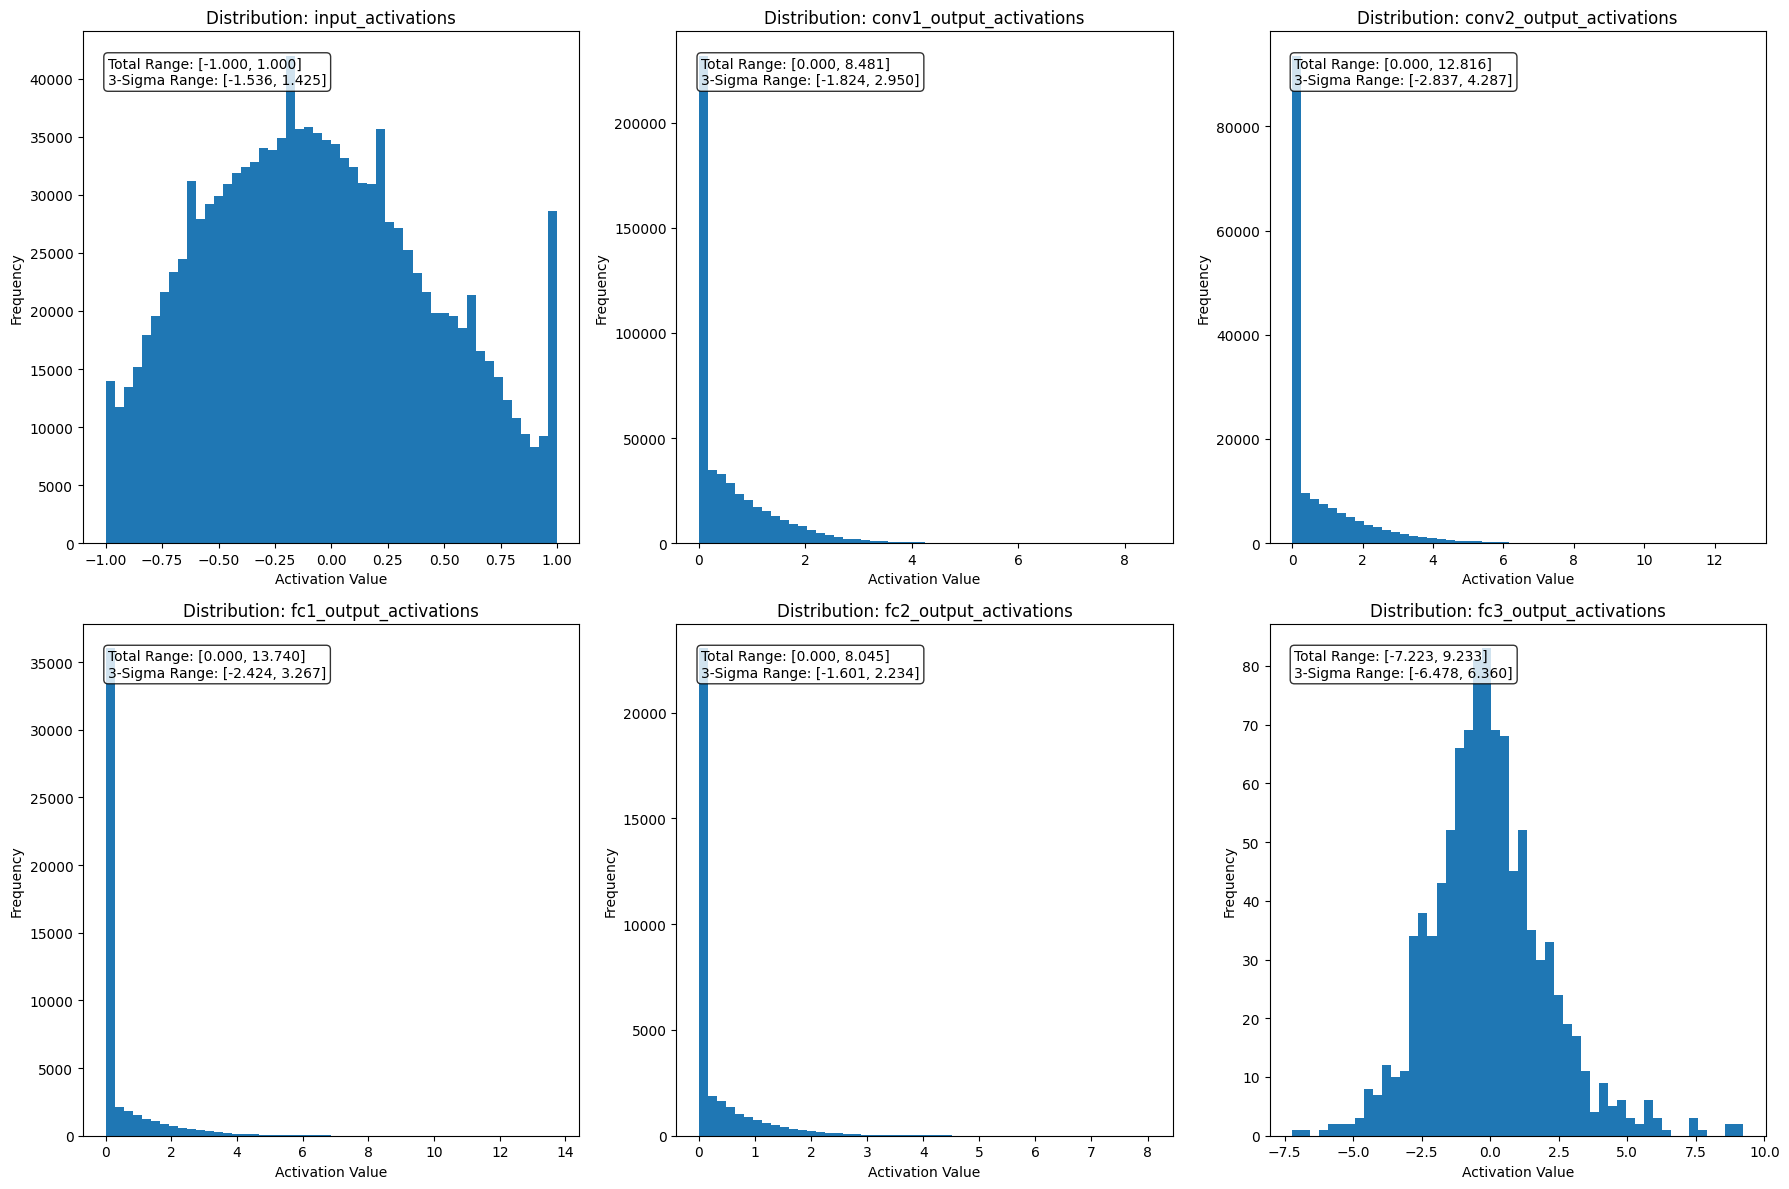

In [26]:
# ADD YOUR CODE HERE to plot distributions of activations

# Plot histograms of the following variables,
# and calculate their total range and 3-sigma range.

#   input_activations
#   conv1_output_activations
#   conv2_output_activations
#   fc1_output_activations
#   fc2_output_activations
#   fc3_output_activations

import matplotlib.pyplot as plt
import numpy as np

# Group the variables in a dictionary for easy iteration
activation_vars = {
    'input_activations': input_activations,
    'conv1_output_activations': conv1_output_activations,
    'conv2_output_activations': conv2_output_activations,
    'fc1_output_activations': fc1_output_activations,
    'fc2_output_activations': fc2_output_activations,
    'fc3_output_activations': fc3_output_activations
}

plt.figure(figsize=(18, 12))

for i, (name, data) in enumerate(activation_vars.items(), 1):
    plt.subplot(2, 3, i)

    plt.hist(data, bins=50)
    plt.title(f'Distribution: {name}')
    plt.xlabel('Activation Value')
    plt.ylabel('Frequency')

    min_val, max_val = np.min(data), np.max(data)
    mean_val, std_val = np.mean(data), np.std(data)
    sigma3_min = mean_val - 3 * std_val
    sigma3_max = mean_val + 3 * std_val

    stats_text = (
        f'Total Range: [{min_val:.3f}, {max_val:.3f}]\n'
        f'3-Sigma Range: [{sigma3_min:.3f}, {sigma3_max:.3f}]'
    )

    plt.annotate(stats_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


# Question 4: Quantize Activations

`y_float = accumulator * (n_x * n_w)`

In [27]:
from typing import List

class NetQuantized(nn.Module):
    def __init__(self, net_with_weights_quantized: nn.Module):
        super(NetQuantized, self).__init__()

        net_init = copy_model(net_with_weights_quantized)

        self.conv1 = net_init.conv1
        self.pool = net_init.pool
        self.conv2 = net_init.conv2
        self.fc1 = net_init.fc1
        self.fc2 = net_init.fc2
        self.fc3 = net_init.fc3

        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:
            def pre_hook(l, x):
                x = x[0]
                if (x < -128).any() or (x > 127).any():
                    raise Exception("Input to {} layer is out of bounds for an 8-bit signed integer".format(l.__class__.__name__))
                if (x != x.round()).any():
                    raise Exception("Input to {} layer has non-integer values".format(l.__class__.__name__))

            layer.register_forward_pre_hook(pre_hook)

        # Calculate the scaling factor for the initial input to the CNN
        self.input_activations = net_with_weights_quantized.input_activations
        self.input_scale = NetQuantized.quantize_initial_input(self.input_activations)

        # Calculate the output scaling factors for all the layers of the CNN
        preceding_layer_scales = []
        for layer in self.conv1, self.conv2, self.fc1, self.fc2, self.fc3:
            layer.output_scale = NetQuantized.quantize_activations(layer.activations, layer.weight.scale, self.input_scale, preceding_layer_scales)
            preceding_layer_scales.append((layer.weight.scale, layer.output_scale))

    @staticmethod
    def quantize_initial_input(pixels: np.ndarray) -> float:
        '''
        Calculate a scaling factor for the images that are input to the first layer of the CNN.

        Parameters:
        pixels (ndarray): The values of all the pixels which were part of the input image during training

        Returns:
        float: A scaling factor that the input should be multiplied by before being fed into the first layer.
               This value does not need to be an 8-bit integer.
        '''

        # ADD YOUR CODE HERE
        # Since this only returns a scale and I can't modify the __init__ to use a zero point
        # this does symmetric quantization.
        return np.max(np.abs(pixels)) / 127

    @staticmethod
    def quantize_activations(activations: np.ndarray, n_w: float, n_initial_input: float, ns: List[Tuple[float, float]]) -> float:
        '''
        Calculate a scaling factor to multiply the output of a layer by.

        Parameters:
        activations (ndarray): The values of all the pixels which have been output by this layer during training
        n_w (float): The scale by which the weights of this layer were multiplied as part of the "quantize_weights" function you wrote earlier
        n_initial_input (float): The scale by which the initial input to the neural network was multiplied
        ns ([(float, float)]): A list of tuples, where each tuple represents the "weight scale" and "output scale" (in that order) for every preceding layer

        Returns:
        float: A scaling factor that the layer output should be multiplied by before being fed into the next layer.
               This value does not need to be an 8-bit integer.
        '''

        # ADD YOUR CODE HERE


        # Used Gemini in "Guided learning" mode to clarify why I need the scales from previous layers


        # if len(ns) == 0:
        #     previous_output_scale = n_initial_input
        # else:
        #     previous_output_scale = ns[-1][1]

        previous_output_scale = n_initial_input

        for w_scale, output_scale in ns:
            # output_scale = S_act / (S_prev * w_scale)
            # Therefore: S_act = output_scale * S_prev * w_scale
            previous_output_scale = output_scale * previous_output_scale * w_scale

        # activation_scale is the desired scale of the activations
        activation_scale = np.max(np.abs(activations)) / 127
        # final_scale is the scale used to achieve the desired scale
        final_scale = activation_scale / (previous_output_scale * n_w)
        return final_scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # You can access the output activation scales like this:
          # fc1_output_scale = self.fc1.output_scale

        # To make sure that the outputs of each layer are integers between -128 and 127, you may need to use the following functions:
        #   * torch.Tensor.round
        #   * torch.clamp

        # TODO: Implement the quantized forward pass.
        # Scale the input, pass it through each layer, and rescale between layers
        # so that inputs to each layer are integers in [-128, 127].

        x = (x / self.input_scale).round()
        # layer one (conv2d, relu, pool)
        x = self.conv1(x)
        x = torch.clamp((x / self.conv1.output_scale).round(), -128, 127)
        x = F.relu(x)
        x = self.pool(x)

        # layer two (conv2d, relu, pool)
        x = self.conv2(x)
        x = torch.clamp((x / self.conv2.output_scale).round(), -128, 127)
        x = F.relu(x)
        x = self.pool(x)

        # flatten
        x = x.view(-1, 16 * 5 * 5)

        # layer 3 (fc, relu)
        x = self.fc1(x)
        x = torch.clamp((x / self.fc1.output_scale).round(), -128, 127)
        x = F.relu(x)

        # layer 4 (fc, relu)
        x = self.fc2(x)
        x = torch.clamp((x / self.fc2.output_scale).round(), -128, 127)
        x = F.relu(x)

        # layer 5 (output) (fc)
        x = self.fc3(x)
        x = torch.clamp((x / self.fc3.output_scale).round(), -128, 127)
        return x

In [28]:
# Merge the information from net_q2 and net_q3 together
net_init = copy_model(net_q2)
net_init.input_activations = deepcopy(net_q3.input_activations)
for layer_init, layer_q3 in zip(net_init.children(), net_q3.children()):
    if isinstance(layer_init, nn.Conv2d) or isinstance(layer_init, nn.Linear):
        layer_init.activations = deepcopy(layer_q3.activations)

net_quantized = NetQuantized(net_init)

In [29]:
score = test(net_quantized, testloader)
print('Accuracy of the network after quantizing both weights and activations: {}%'.format(score))

Accuracy of the network after quantizing both weights and activations: 48.4%


# Question 5: Quantize Biases

In [30]:
class NetWithBias(nn.Module):
    def __init__(self):
        super(NetWithBias, self).__init__()

        self.conv1 = nn.Conv2d(3, 6, 5, bias=False)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5, bias=False)
        self.fc1 = nn.Linear(16 * 5 * 5, 120, bias=False)
        self.fc2 = nn.Linear(120, 84, bias=False)
        self.fc3 = nn.Linear(84, 10, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net_with_bias = NetWithBias().to(device)

In [31]:
train(net_with_bias, trainloader)

[1,  2000] loss: 2.186
[1,  4000] loss: 1.823
[1,  6000] loss: 1.631
[1,  8000] loss: 1.600
[1, 10000] loss: 1.535
[1, 12000] loss: 1.489
[2,  2000] loss: 1.410
[2,  4000] loss: 1.419
[2,  6000] loss: 1.383
[2,  8000] loss: 1.354
[2, 10000] loss: 1.345
[2, 12000] loss: 1.327
Finished Training


In [32]:
score = test(net_with_bias, testloader)
print('Accuracy of the network (with a bias) on the test images: {}%'.format(score))

Accuracy of the network (with a bias) on the test images: 53.13%


In [33]:
register_activation_profiling_hooks(net_with_bias)
test(net_with_bias, trainloader, max_samples=400)
net_with_bias.profile_activations = False

In [34]:
net_with_bias_with_quantized_weights = copy_model(net_with_bias)
quantize_layer_weights(net_with_bias_with_quantized_weights)

score = test(net_with_bias_with_quantized_weights, testloader)
print('Accuracy of the network on the test images after all the weights are quantized but the bias isn\'t: {}%'.format(score))

Accuracy of the network on the test images after all the weights are quantized but the bias isn't: 48.63%


In [35]:
class NetQuantizedWithBias(NetQuantized):
    def __init__(self, net_with_weights_quantized: nn.Module):
        super(NetQuantizedWithBias, self).__init__(net_with_weights_quantized)

        preceding_scales = [(layer.weight.scale, layer.output_scale) for layer in self.children() if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear)][:-1]

        self.fc3.bias.data = NetQuantizedWithBias.quantized_bias(
            self.fc3.bias.data,
            self.fc3.weight.scale,
            self.input_scale,
            preceding_scales
        )

        if (self.fc3.bias.data < -2147483648).any() or (self.fc3.bias.data > 2147483647).any():
            raise Exception("Bias has values which are out of bounds for an 32-bit signed integer")
        if (self.fc3.bias.data != self.fc3.bias.data.round()).any():
            raise Exception("Bias has non-integer values")

    @staticmethod
    def quantized_bias(bias: torch.Tensor, n_w: float, n_initial_input: float, ns: List[Tuple[float, float]]) -> torch.Tensor:
        '''
        Quantize the bias so that all values are integers between -2147483648 and 2147483647.

        Parameters:
        bias (Tensor): The floating point values of the bias
        n_w (float): The scale by which the weights of this layer were multiplied
        n_initial_input (float): The scale by which the initial input to the neural network was multiplied
        ns ([(float, float)]): A list of tuples, where each tuple represents the "weight scale" and "output scale" (in that order) for every preceding layer

        Returns:
        Tensor: The bias in quantized form, where every value is an integer between -2147483648 and 2147483647.
                The "dtype" will still be "float", but the values themselves should all be integers.
        '''
        # previous_output_scale = n_initial_input

        # for w_scale, output_scale in ns:
        #     # output_scale = S_act / (S_prev * w_scale)
        #     # Therefore: S_act = output_scale * S_prev * w_scale
        #     previous_output_scale = output_scale * previous_output_scale * w_scale

        # activation_scale = np.max(np.abs(activations)) / 127
        # final_scale = activation_scale / (previous_output_scale * n_w)
        # return final_scale

        # ADD YOUR CODE HERE
        # n_initial_input, and the preceding layer scales in ns.

        previous_output_scale = n_initial_input

        for w_scale, previous_conversion_factor in ns:
            previous_output_scale = previous_output_scale * w_scale * previous_conversion_factor

        # flip factor because we are multiplying the activations, not dividing
        conversion_factor = 1.0 / (previous_output_scale * n_w)

        return torch.clamp((bias * conversion_factor).round(), min=-2147483648, max=2147483647)

In [36]:
net_quantized_with_bias = NetQuantizedWithBias(net_with_bias_with_quantized_weights)

In [37]:
score = test(net_quantized_with_bias, testloader)
print('Accuracy of the network on the test images after all the weights and the bias are quantized: {}%'.format(score))

Accuracy of the network on the test images after all the weights and the bias are quantized: 53.28%


# Question 6: Pruning and Fine-Tuning

In [38]:
import torch.nn.utils.prune as prune

def apply_unstructured_pruning(model: nn.Module, amount: float):
    '''
    Apply L1 unstructured pruning to all Conv2d and Linear layers of the model.
    After pruning, a fraction of the weights (specified by `amount`) will be set
    to zero based on their L1 magnitude (smallest-magnitude weights are removed).

    Parameters:
    model (nn.Module): The neural network model to prune
    amount (float): The fraction of weights to prune (e.g., 0.5 means 50% sparsity)

    Hint: iterate over model.modules() and for each Conv2d or Linear layer call
          prune.l1_unstructured(layer, name='weight', amount=amount)
    '''

    for layer in model.modules():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            prune.l1_unstructured(layer, name='weight', amount=amount)

def count_zero_params(model: nn.Module) -> float:
    '''
    Return the percentage of zeroed-out weight parameters across all Conv2d and
    Linear layers of the model.

    Parameters:
    model (nn.Module): The neural network model

    Returns:
    float: The percentage of weights that are zero (0.0 to 100.0)

    Hint: for each Conv2d/Linear layer, use layer.weight.nelement() for the total
          count and (layer.weight == 0).sum().item() for the zero count.
    '''

    zero_count = 0
    total_count = 0

    for layer in model.modules():
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            # Add to the running totals instead of overwriting
            zero_count += (layer.weight == 0).sum().item()
            total_count += layer.weight.nelement()
    return zero_count / total_count * 100

Pruning is another model compression technique that removes weights by setting them to zero, making the model *sparse*. Apply L1 unstructured magnitude pruning at each sparsity level to the trained CNN and evaluate accuracy **before** fine-tuning.

**Training time note:** Fine-tuning below will retrain each pruned model for 2 epochs. Expect a few minutes of GPU time per sparsity level.

In [43]:
sparsity_levels = [0.3, 0.5, 0.7, 0.9]
original_accuracy = test(net, testloader)

pruned_models = {}
accuracies_before_finetune = {}

  # ADD YOUR CODE HERE
for sparsity in sparsity_levels:
    #   1. Copy the trained model using copy_model(net)
    pruned_model = copy_model(net)
    #   2. Apply pruning using your apply_unstructured_pruning function
    apply_unstructured_pruning(pruned_model, sparsity)
    #   3. Print the actual sparsity percentage using count_zero_params
    print(count_zero_params(pruned_model))
    #   4. Evaluate accuracy on testloader using the test() function
    score = test(pruned_model, testloader)
    print('Accuracy of the network on the test images: {}%'.format(score))
    #   5. Store the pruned model in pruned_models[amount]
    #      and the accuracy in accuracies_before_finetune[amount]
    pruned_models[sparsity] = pruned_model
    accuracies_before_finetune[sparsity] = score

30.0
Accuracy of the network on the test images: 49.11%
50.0
Accuracy of the network on the test images: 46.99%
70.0
Accuracy of the network on the test images: 41.05%
90.0
Accuracy of the network on the test images: 16.84%


Fine-tune each pruned model for 2 epochs using a **smaller learning rate** (e.g., 1/10 of the original). The pruning masks are automatically preserved during gradient updates, so zeroed weights stay zero.

In [44]:
def finetune(model: nn.Module, dataloader: DataLoader, lr: float = 0.0001):
    '''
    Fine-tune a (pruned) model with a smaller learning rate.
    This uses the same training loop as train(), but with a reduced learning rate
    (default 0.0001, i.e., 1/10 of the original 0.001) and only 2 epochs.
    The pruning masks applied by torch.nn.utils.prune are preserved automatically
    during gradient updates.

    Parameters:
    model (nn.Module): The model to fine-tune (typically a pruned model)
    dataloader (DataLoader): The training data loader
    lr (float): Learning rate for fine-tuning (default: 0.0001)
    '''
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    for epoch in range(2):
        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 2000 == 1999:
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
                running_loss = 0.0

    print('Finished Fine-Tuning')

accuracies_after_finetune = {}

for amount in sparsity_levels:
    pruned_net = pruned_models[amount]

    # 1. Fine-tune pruned_net on trainloader using finetune()
    finetune(pruned_net, trainloader)
    # 2. Evaluate accuracy on testloader using test()
    score = test(pruned_net, testloader)
    print('Accuracy of the network on the test images: {}%'.format(score))
    # 3. Store the result in accuracies_after_finetune[amount]
    accuracies_after_finetune[amount] = score
    # 4. Print the sparsity level and accuracy after fine-tuning
    print(f'Sparsity: {count_zero_params(pruned_net)}, Accuracy: {score}')

[1,  2000] loss: 1.196
[1,  4000] loss: 1.179
[1,  6000] loss: 1.152
[1,  8000] loss: 1.135
[1, 10000] loss: 1.139
[1, 12000] loss: 1.134
[2,  2000] loss: 1.137
[2,  4000] loss: 1.112
[2,  6000] loss: 1.105
[2,  8000] loss: 1.101
[2, 10000] loss: 1.105
[2, 12000] loss: 1.116
Finished Fine-Tuning
Accuracy of the network on the test images: 58.04%
Sparsity: 30.0, Accuracy: 58.04
[1,  2000] loss: 1.244
[1,  4000] loss: 1.202
[1,  6000] loss: 1.183
[1,  8000] loss: 1.167
[1, 10000] loss: 1.147
[1, 12000] loss: 1.151
[2,  2000] loss: 1.119
[2,  4000] loss: 1.152
[2,  6000] loss: 1.156
[2,  8000] loss: 1.125
[2, 10000] loss: 1.118
[2, 12000] loss: 1.122
Finished Fine-Tuning
Accuracy of the network on the test images: 57.96%
Sparsity: 50.0, Accuracy: 57.96
[1,  2000] loss: 1.411
[1,  4000] loss: 1.271
[1,  6000] loss: 1.253
[1,  8000] loss: 1.242
[1, 10000] loss: 1.254
[1, 12000] loss: 1.220
[2,  2000] loss: 1.201
[2,  4000] loss: 1.189
[2,  6000] loss: 1.193
[2,  8000] loss: 1.196
[2, 10000]

Plot a grouped bar chart comparing the test accuracy across all four sparsity levels. For each level, show three bars: **original (unpruned)**, **post-pruning (before fine-tuning)**, and **post-fine-tuning**.

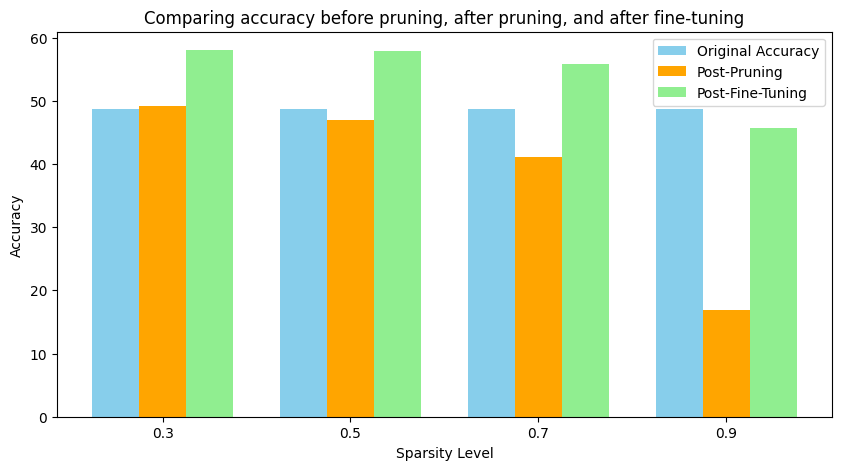

In [47]:
# ADD YOUR CODE HERE
# Plot a grouped bar chart with sparsity levels on the x-axis and accuracy on the y-axis.
# For each sparsity level, show three bars:
#   1. Original accuracy (original_accuracy)
#   2. Post-pruning accuracy (accuracies_before_finetune[amount])
#   3. Post-fine-tuning accuracy (accuracies_after_finetune[amount])

#
# Label the axes, include a legend, and give the chart a descriptive title.

x = np.arange(len(sparsity_levels))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
orig_accs = [original_accuracy] * len(sparsity_levels)

ax.bar(x - width, orig_accs, width, label='Original Accuracy', color='skyblue')
ax.bar(x, [accuracies_before_finetune[s] for s in sparsity_levels], width, label='Post-Pruning', color='orange')
ax.bar(x + width, [accuracies_after_finetune[s] for s in sparsity_levels], width, label='Post-Fine-Tuning', color='lightgreen')

ax.set_xlabel('Sparsity Level')
ax.set_ylabel('Accuracy')
ax.set_title('Comparing accuracy before pruning, after pruning, and after fine-tuning')

ax.set_xticks(x)
ax.set_xticklabels(sparsity_levels)

ax.legend()


In 2–3 sentences, explain what you observe about the relationship between sparsity level and accuracy recovery after fine-tuning. Include your response in the PDF writeup.

# Question 7: Pruning Before vs. After Training

In [ ]:
# In Q6 you already pruned the trained model at multiple sparsity levels.
# Reuse the 50% result as the "prune AFTER training" baseline:
acc_prune_after = accuracies_before_finetune[0.5]
print(f'Prune after training (from Q6) — accuracy: {acc_prune_after:.2f}%')

In [ ]:
# --- Strategy 2: Prune BEFORE training ---
#
# Create a new (randomly initialized) Net, apply 50% L1 unstructured pruning
# BEFORE any training, then train the sparse network for 2 epochs using the
# train() function, and evaluate test accuracy.

# ADD YOUR CODE HERE
# 1. Create a new Net() and move it to device
# 2. Apply 50% pruning using apply_unstructured_pruning
# 3. Print the sparsity at initialization using count_zero_params
# 4. Train on trainloader for 2 epochs using train()
# 5. Evaluate accuracy on testloader and store in acc_prune_before

Plot a bar chart comparing the test accuracy of the three configurations: **original (unpruned, trained)**, **pruned after training**, and **pruned before training (then trained)**.

In [ ]:
# ADD YOUR CODE HERE
# Plot a bar chart with three bars:
#   1. Original accuracy (original_accuracy)
#   2. Pruned after training (acc_prune_after)
#   3. Pruned before training, then trained (acc_prune_before)
#
# Label the axes and include a descriptive title.

In 2–3 sentences, explain why pruning before training produces the accuracy result you observed. What does this suggest about the role of learned weight magnitudes in determining which weights should be pruned? Include your response in the PDF writeup.